# RAPID 26.5ºN
This notebook demonstrates creating sections at 26.5ºN — the location of the RAPID-MOCHA array.

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import iconspy as ispy
from iconspy.tests.conftest import get_ds_tgrid_lr

## Grid setup

In [3]:
ds_tgrid = get_ds_tgrid_lr()  # This can be replaced with your own model tgrid
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)
ds_IsD

<xarray.Dataset> Size: 7MB
Dimensions:                 (cell: 15105, vertex: 8067, edge: 23207, nc_e: 2,
                             nv_c: 3, ne_c: 3, nv_v: 6, ne_v: 6, nv_e: 2,
                             nc_v: 6, nc_c: 3, cart: 3)
Coordinates:
  * cell                    (cell) int32 60kB 0 1 2 3 ... 15102 15103 15104
    clon                    (cell) float64 121kB 69.12 73.0 ... 74.57 76.01
    clat                    (cell) float64 121kB 72.74 74.52 ... -46.83 -44.85
  * vertex                  (vertex) int32 32kB 0 1 2 3 ... 8063 8064 8065 8066
    vlon                    (vertex) float64 65kB 73.0 69.39 ... 80.59 77.56
    vlat                    (vertex) float64 65kB 73.27 71.49 ... -45.35 -45.49
  * edge                    (edge) int32 93kB 0 1 2 3 ... 23204 23205 23206
    elon                    (edge) float64 186kB 71.11 76.98 ... 75.34 76.04
    elat                    (edge) float64 186kB 72.39 73.25 ... -46.52 -45.54
Dimensions without coordinates: nc_e, nv_c, ne_c, nv_v, ne_v, nv_e, nc_v, nc_c,
                                cart
Data variables: (12/40)
    grid_sphere_radius      float64 8B 6.371e+06
    grav                    float64 8B 9.807
    earth_angular_velocity  float64 8B 7.292e-05
    rho0                    float64 8B 1.025e+03
    rhoi                    float64 8B 917.0
    rhos                    float64 8B 300.0
    ...                      ...
    edge_cart_vec           (edge, cart) float64 557kB 0.09797 ... -0.7137
    dual_edge_cart_vec      (edge, cart) float64 557kB 0.09801 ... -0.7136
    edge_prim_norm          (edge, cart) float64 557kB 0.6463 -0.7466 ... 0.7001
    fc                      (cell) float64 121kB 0.0001393 ... -0.0001029
    fe                      (edge) float64 186kB 0.000139 ... -0.0001041
    fv                      (vertex) float64 65kB 0.0001397 ... -0.000104
Attributes:
    converted_tgrid:      True
    boundary_BallTree:    <iconspy.balltree.IspyBoundaryBallTree object at 0x...
    wet_BallTree:         <iconspy.balltree.IspyWetBallTree object at 0x7ffb5...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    IsD_compatible_flag:  True

## Create the sections

At RAPID, three sections are used to calculate the AMOC's strength. The first is across the Florida Current which is observed using a cable. The second is the western boundary wedge which stretches a little west from the Bahamas and is measured with moored current meters. The third is the interior transport which is calculated from geostrophic transport. In practice the western boundary wedge transport is quite small so is often merged with the Florida Current transport when we think about comparable measurements in models. As such we will define two sections along the RAPID line.

The first is the combined Florida Current/Western boundary wedge section, and the second is the interior section. We will define three stations to form these sections: "RAPID West", "RAPID Gulf" and "RAPID East"

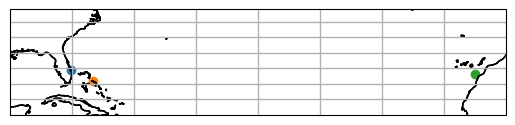

In [6]:
# Define the target stations
rapid_target_west = ispy.TargetStation(
    name="RAPID West",
    lon=-80,
    lat=26.5,
    boundary=True
)

rapid_target_gulf = ispy.TargetStation(
    name="RAPID Gulf",
    lon= -76.25,
    lat=26.5,
    boundary=False
)

rapid_target_east = ispy.TargetStation(
    name="RAPID East",
    lon=-14,
    lat=26.5,
    boundary=True
)

# Find the closest model stations to our target stations
rapid_targets = [rapid_target_west, rapid_target_gulf, rapid_target_east]
rapid_model_stations = [target.to_model_station(ds_IsD) for target in rapid_targets]

# Check the target and model sections appear roughly where we expect them too
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
for station in rapid_model_stations:
    station.plot(ax=ax)
ax.set_extent([-90, -10, 20, 30])

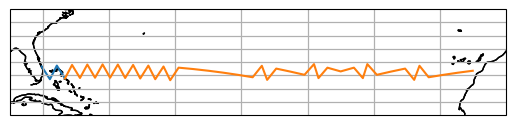

In [7]:
# Construct sections from our model stations

florida_current = ispy.Section(
    name="Florida Current",
    model_station_a=rapid_model_stations[0],
    model_station_b=rapid_model_stations[1],
    ds_IsD=ds_IsD,
    section_type="isolat",
)

interior = ispy.Section(
    name="Interior 26.5N",
    model_station_a=rapid_model_stations[1],
    model_station_b=rapid_model_stations[2],
    ds_IsD=ds_IsD,
    section_type="isolat",
)

# Visualise the section
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
florida_current.plot(ax=ax)
interior.plot(ax=ax)
ax.set_extent([-85, -10, 20, 30])

Convert the section objects into xarray datasets we can reuse later

In [11]:
attrs = {
    "Created in": Path(f"{ispy.__path__[0]}/../examples/rapid-26N.ipynb").resolve(),
}

ds_florida_current = florida_current.to_ispy_section(attrs=attrs)
ds_interior = interior.to_ispy_section(attrs=attrs)

In [12]:
ds_florida_current

<xarray.Dataset> Size: 220B
Dimensions:           (step_in_path: 3, step_in_path_v: 4)
Coordinates:
  * step_in_path      (step_in_path) int64 24B 0 1 2
    elon              (step_in_path) float64 24B -79.58 -78.44 -77.3
    elat              (step_in_path) float64 24B 26.37 26.44 26.5
  * step_in_path_v    (step_in_path_v) int64 32B 0 1 2 3
    vlon              (step_in_path_v) float64 32B -80.21 -78.96 -77.92 -76.69
    vlat              (step_in_path_v) float64 32B 27.33 25.41 27.47 25.52
Data variables:
    edge_path         (step_in_path) int32 12B 8094 8098 8108
    vertex_path       (step_in_path_v) int32 16B 2947 2946 2950 2953
    path_orientation  (step_in_path) float64 24B 1.0 -1.0 1.0
Attributes:
    date:          2026-07-14 13:05:21
    ispy version:  0.2.0
    uuidOfHGrid:   5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    section name:  Florida Current
    Created by:    m301014
    Created in:    /work/mh0256/m301014/iconspy/examples/rapid-26N.ipynb

In [13]:
ds_interior

<xarray.Dataset> Size: 3kB
Dimensions:           (step_in_path: 41, step_in_path_v: 42)
Coordinates:
  * step_in_path      (step_in_path) int64 328B 0 1 2 3 4 5 ... 36 37 38 39 40
    elon              (step_in_path) float64 328B -76.16 -75.01 ... -16.15
    elat              (step_in_path) float64 328B 26.55 26.58 ... 26.24 26.55
  * step_in_path_v    (step_in_path_v) int64 336B 0 1 2 3 4 5 ... 37 38 39 40 41
    vlon              (step_in_path_v) float64 336B -76.69 -75.61 ... -15.03
    vlat              (step_in_path_v) float64 336B 25.52 27.57 ... 26.4 26.69
Data variables:
    edge_path         (step_in_path) int32 164B 8150 8152 7600 ... 8486 8485
    vertex_path       (step_in_path_v) int32 168B 2953 2961 2777 ... 3091 3093
    path_orientation  (step_in_path) float64 328B 1.0 1.0 1.0 ... -1.0 1.0 1.0
Attributes:
    date:          2026-07-14 13:05:21
    ispy version:  0.2.0
    uuidOfHGrid:   5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    section name:  Interior 26.5N
    Created by:    m301014
    Created in:    /work/mh0256/m301014/iconspy/examples/rapid-26N.ipynb